# Feature Selection/Extraction
In this project we will use the library scikit-learn to work with the league of legends dataset we will apply some feature selection techniques and experiment with dimensionality reduction by using: Principal Component Analysis (PCA)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay

We load the league of legends data from kaggle, the `X` data contains information about the league of legends games, we will be using that data to predict the class `y`, which tells us if a match is won or not. 
The details on the different features name and definition can be found here: https://www.kaggle.com/datasets/nathansmallcalder/lol-match-history-and-summoner-data-80k-matches/data?select=MatchStatsTbl.csv

In [2]:
df = pd.read_csv(r"C:\Users\fenos\Documents\stuff\jupyter\Machine Learning 2025_2026\MatchStatsTbl.csv") #!!!change the file directory to your own file directory path

X = df.copy()
y = df["Win"].astype(int)


## Exploring the Data 


Let's explore the dataset using head(), info(), and describe() from pandas to review feature types and identify missing data.

In [3]:
print(X.head())
print(X.info())
print(X.describe())

   MatchStatsId  SummonerMatchFk  MinionsKilled  DmgDealt  DmgTaken  \
0             1                1             30      4765     12541   
1             2                2             29      8821     14534   
2             3                3             34      6410     19011   
3             4                4             51     22206     14771   
4             5                5              0     39106     33572   

   TurretDmgDealt  TotalGold    Lane  Win  item1  ...  PrimarySlot3  \
0               0       7058  BOTTOM    0   3870  ...          8453   
1               1       9618  BOTTOM    0   3870  ...          8453   
2               3       9877  BOTTOM    1   3870  ...          8237   
3               3      12374    NONE    1   6655  ...          8106   
4               0      15012     TOP    1   4015  ...             0   

   SecondarySlot1  SecondarySlot2  SummonerSpell1  SummonerSpell2  \
0            8345            8347               4               7   
1       

### Dropping useless features
Now, we are going to drop the `MatchStatsId` and `SummonerMatchFk` features which are not very informative since they are numbers of the match to identify it.

We also drop the `Win` feature from X since we want to predict it and not have it as a feature in this case. (We could also study what was the champions picked, gold lead etc. considering win as a feature)


In [4]:
# drop function panda
X.drop(["Win", "MatchStatsId", "SummonerMatchFk"], axis=1, inplace=True)


### Dropping missing values
We will check if any of the remaining features have missing values using `isnull()` and remove those with missing value ratios above 25% using the function `drop()` from `pandas`. 

In [5]:
print(X.isnull().mean())

MinionsKilled           0.0
DmgDealt                0.0
DmgTaken                0.0
TurretDmgDealt          0.0
TotalGold               0.0
Lane                    0.0
item1                   0.0
item2                   0.0
item3                   0.0
item4                   0.0
item5                   0.0
item6                   0.0
kills                   0.0
deaths                  0.0
assists                 0.0
PrimaryKeyStone         0.0
PrimarySlot1            0.0
PrimarySlot2            0.0
PrimarySlot3            0.0
SecondarySlot1          0.0
SecondarySlot2          0.0
SummonerSpell1          0.0
SummonerSpell2          0.0
CurrentMasteryPoints    0.0
EnemyChampionFk         0.0
DragonKills             0.0
BaronKills              0.0
visionScore             0.0
dtype: float64


So we have nothing to drop since no missing values with over 0.25 threshold, actually all of these features are filled.

### Part 4
No features contain missing values, so no rows need to be dropped.

### Part 5
We will check which features are categorical and which are numerical. For the `lane` variable, we want to code a one-hot encoding. 

In [6]:
X.describe()
#X.dtypes

,MinionsKilled,DmgDealt,DmgTaken,TurretDmgDealt,TotalGold,item1,item2,item3,item4,item5,...,PrimarySlot3,SecondarySlot1,SecondarySlot2,SummonerSpell1,SummonerSpell2,CurrentMasteryPoints,EnemyChampionFk,DragonKills,BaronKills,visionScore
count,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,...,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000,193758.000000
mean,108.712461,25219.012794,29940.714272,1.760536,12240.161557,37492.136268,35696.602499,46549.352693,31299.290151,30131.880227,...,7156.252867,7291.805061,7277.022187,284.030590,285.654419,207.004273,204.929949,0.290078,0.058872,19.930873
std,90.754678,17421.172395,17921.375493,1.962188,4596.605153,98895.209600,93965.720115,123692.335059,82464.036516,83316.387832,...,2718.202201,2777.116310,2771.151791,727.558006,726.897496,253.065805,255.889617,0.759657,0.255348,22.431461
min,0.000000,0.000000,0.000000,0.000000,500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,23.000000,13237.000000,18701.000000,0.000000,9251.000000,3006.000000,3036.000000,3020.000000,3009.000000,1052.000000,...,8014.000000,8139.000000,8106.000000,4.000000,4.000000,48.000000,45.000000,0.000000,0.000000,3.000000
50%,97.500000,21716.000000,26732.000000,1.000000,11926.000000,3143.000000,3152.000000,3118.000000,3111.000000,3072.000000,...,8135.000000,8299.000000,8242.000000,4.000000,11.000000,105.000000,103.000000,0.000000,0.000000,15.000000
75%,188.000000,32715.000000,37405.000000,3.000000,14905.000000,6610.000000,6653.000000,4645.000000,4645.000000,4017.000000,...,8299.000000,8401.000000,8347.000000,14.000000,14.000000,235.000000,234.000000,0.000000,0.000000,25.000000
max,549.000000,314904.000000,435808.000000,12.000000,48347.000000,447123.000000,447123.000000,447123.000000,447123.000000,447123.000000,...,8453.000000,9111.000000,9111.000000,2202.000000,2202.000000,950.000000,950.000000,6.000000,4.000000,215.000000


In [7]:
#identification of categorical and numerical features
categorical_features = [col for col in X.columns if X[col].dtype == "object"]
numerical_features = [col for col in X.columns if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numerical features count:", len(numerical_features))

#onehot encoding
X = pd.get_dummies(X, columns=categorical_features, dtype=int)

X.info()



Categorical features: ['Lane']
Numerical features count: 27
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193758 entries, 0 to 193757
Data columns (total 33 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   MinionsKilled         193758 non-null  int64
 1   DmgDealt              193758 non-null  int64
 2   DmgTaken              193758 non-null  int64
 3   TurretDmgDealt        193758 non-null  int64
 4   TotalGold             193758 non-null  int64
 5   item1                 193758 non-null  int64
 6   item2                 193758 non-null  int64
 7   item3                 193758 non-null  int64
 8   item4                 193758 non-null  int64
 9   item5                 193758 non-null  int64
 10  item6                 193758 non-null  int64
 11  kills                 193758 non-null  int64
 12  deaths                193758 non-null  int64
 13  assists               193758 non-null  int64
 14  PrimaryKeyStone       19

### Part 6
We are going to split `X` and `y` into training and testing sets with 20% of the data in the testing set by using `rain_test_split()` from `sklearn`.

In [8]:
# split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

### Part 7
We will now train a classifier on the training dataset. 
For that, we will use a pipeline that preprocesses the data and then fits it into a classifier.

The idea is to try different classifiers:
- `LogisticRegression()`
- `SVC(kernel='linear')`
- `KNeighborsClassifier(n_neighbors=3)`
- `DecisionTreeClassifier()`
- `RandomForestClassifier()`

we will discuss about which one gives the best(most accurate) results

In [9]:
classifiers = {
    "LogisticRegression": LogisticRegression(),
    "SVC_linear": SVC(kernel="linear"),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42)
}

In [10]:
for name, clf in classifiers.items():
    model = Pipeline(steps=[
        ('normalizer', StandardScaler()),
        ('classifier', clf)
    ])
    #train the model
    model.fit(X_train, y_train)

    # predict on the test set
    y_predict = model.predict(X_test)

    # Assess the quality of the prediction
    print(f"{name} - Number of errors:", np.sum(y_predict != y_test))

LogisticRegression - Number of errors: 6534
SVC_linear - Number of errors: 6494
KNN - Number of errors: 6232
DecisionTree - Number of errors: 2686
RandomForest - Number of errors: 1631


The comparison of classifiers shows performance differences across the five tested models. The linear models like Logistic Regression (6 520 errors) and SVM with a linear kernel (6 490 errors) performed similarly, capturing trends in a linear sense. 

The K-Nearest Neighbors model achieved a small improvement (6 357 errors), is kind of better in high featured problems like ours. 

The Decision Tree model showed a rise in performance with 2 618 errors, as it can capture non-linear and interaction effects between features. 

Finally, the Random Forest model achieved the best results with just 1 635 errors, confirming that ensemble methods leveraging multiple trees provide the most robust and accurate predictions for this dataset. 

Overall, performance improves as we go for more complex algorithms, with Random Forest being the best for our case.

In [11]:
def plot_decision_boundaries(model, X, ypred, ytrue):                                                                      
    _, ax = plt.subplots()
    
    # Plot decision boundary of the model
    DecisionBoundaryDisplay.from_estimator(
        model,
        X[:, :2],
        ax=ax,
        cmap='cool',
        response_method="predict",
        plot_method="pcolormesh",
        shading="auto",
    )

    # Plot the testing points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=ytrue.astype(float),
        marker='o',
        cmap='jet',
    )
    
    # Plot the predicted points
    plt.scatter(
        X[ypred != ytrue, 0],
        X[ypred != ytrue, 1],
        c=ypred[ypred != ytrue].astype(float),
        marker='*',
        cmap='jet',
    )
    

### Part 8
 We will apply PCA to the preprocessed data before fitting it to reduce the dimension of the features, we then change the number of components used in PCA and check how that affects the testing accuracy.

In [12]:
pca = PCA(n_components=2) 
pca.fit(X_train)
Xnew_train = pca.transform(X_train)
Xnew_test = pca.transform(X_test)

In [13]:
model = Pipeline(steps=[
    ('normalizer', StandardScaler()),
    ('classifier', LogisticRegression())
])

In [14]:
# Fit the training set here
model.fit(Xnew_train, y_train)

# Predict the class of the testing dataset
ynew_predict = model.predict(Xnew_test)

# Assess the quality of the prediction
print("Number of errors:", np.sum(ynew_predict != y_test))

Number of errors: 18883


The model with PCA (n = 2 components) produced approximately 18 861 errors, compared to 6 547 errors without PCA which is an increase by a factor of about 2.8.

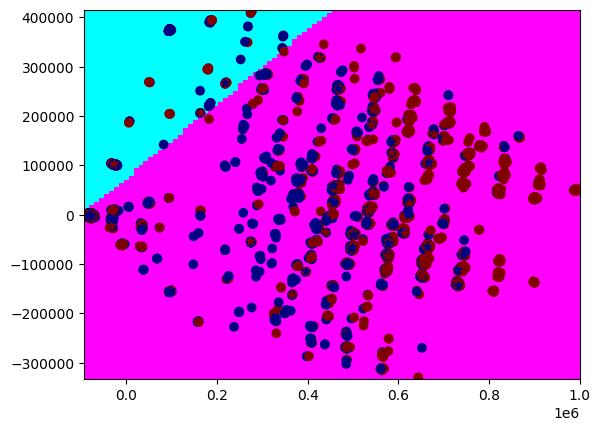

In [15]:
plot_decision_boundaries(model, Xnew_test, y_predict, y_test)

In [16]:
for k in [2, 5, 10, 20, 30]:
    pca = PCA(n_components=k, random_state=42)
    pca.fit(X_train)
    Xtr = pca.transform(X_train)
    Xte = pca.transform(X_test)

    model = Pipeline(steps=[
        ('normalizer', StandardScaler()),
        ('classifier', LogisticRegression())
    ])
    model.fit(Xtr, y_train)
    yhat = model.predict(Xte)
    errors = np.sum(yhat != y_test)
    acc = 1 - errors / len(y_test)
    print(f"n_components={k} -> errors: {errors}, accuracy: {acc:.4f}")


n_components=2 -> errors: 18883, accuracy: 0.5127
n_components=5 -> errors: 18186, accuracy: 0.5307
n_components=10 -> errors: 13804, accuracy: 0.6438
n_components=20 -> errors: 12344, accuracy: 0.6815
n_components=30 -> errors: 6592, accuracy: 0.8299


In [17]:
for k in [2, 5, 10, 20, 30]:
    pca = PCA(n_components=k, random_state=42)
    pca.fit(X_train)
    Xtr = pca.transform(X_train)
    Xte = pca.transform(X_test)

    model = Pipeline(steps=[
        ('normalizer', StandardScaler()),
        ('classifier', RandomForestClassifier())
    ])
    model.fit(Xtr, y_train)
    yhat = model.predict(Xte)
    errors = np.sum(yhat != y_test)
    acc = 1 - errors / len(y_test)
    print(f"n_components={k} -> errors: {errors}, accuracy: {acc:.4f}")


n_components=2 -> errors: 5355, accuracy: 0.8618
n_components=5 -> errors: 5050, accuracy: 0.8697
n_components=10 -> errors: 3608, accuracy: 0.9069
n_components=20 -> errors: 3726, accuracy: 0.9039
n_components=30 -> errors: 2422, accuracy: 0.9375


We have maximal precision when we have more than 2 features as expected, we verified this with 2 models namely: Logistic Regression and Random Forest. 

Random Forest seems to be the most performant algorithm for this database with 93.7% accuracy where Logistic Regression has 83.0% for k=30.

### Feature Extraction/Interpretation

We will use the Random Forest algorithm to extract which features are the most valuable for winning a league of legends game.

TurretDmgDealt          0.211252
deaths                  0.109748
assists                 0.075259
TotalGold               0.068483
DmgTaken                0.050754
kills                   0.048799
DmgDealt                0.042945
MinionsKilled           0.031307
item1                   0.024189
EnemyChampionFk         0.024044
item6                   0.023575
item2                   0.023300
item5                   0.023162
item3                   0.022874
CurrentMasteryPoints    0.022437
dtype: float64

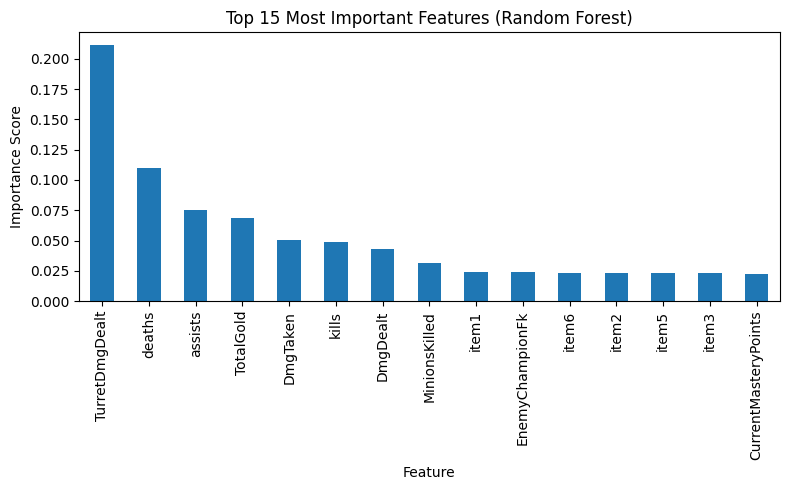

In [19]:
# Get feature importances from the trained Random Forest
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Display the 15 most important features
top_features = importances.head(15)
display(top_features)

# Plot the feature importances
plt.figure(figsize=(8,5))
top_features.plot(kind='bar')
plt.title("Top 15 Most Important Features (Random Forest)")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()


When I look at this graph as a league of legends player I try to make sense of it. 

First of all the goal of the game is to destroy the enemy base (also called nexus) which is protected by towers which we aim to push and take over to facilitate the destruction of the enemy nexus so this makes really sense, most people would be attracted to killing the enemy champions which also is the 6th most important feature but it doesn't really help "winning" the game if all we are doing is relentlessly killing the enemy, we have to convert that into some objective which are mostly turrets. 

I want to comment on deaths and kills and why they aren't valued the same, the reasoning is logical once again. If we kill the enemy repeadetly but get nothing in return we are doomed to lose the game more often than not. If we however keep on dying, if the enemy is smart they can convert our deaths into objectives themselves which means our deaths are more meaningfull than our kills on the enemy most often than not. This is because people most of the time cannot convert their kill leads into objectives but not dying helps them stay on the map more and make better decisions instead of gaining nothing because they were dead in the first place. 

Assists would mean there is more teamplay in one team than another because the more assists there is more organized the plays are in general which is superior to an egoistical gameplay but it might not always work if we are spending too much time as a group also so this doesn't have top priority.

Total gold is also a valuable resource to be able to buy items and destroy the enemy base but if the game takes a long time it reduces the gold value since everyone can buy items in a long time so gold at the end is just a mean to end the game quicker.

Damage Taken, Damage Dealt, Minions Killed are all combat related statistics which are really useful but not that useful compared to what we have been talking about.

First item is a tiny bit more dominant than other items since some games are much shorter due to one team giving up more often than not because people who play this game aren't that much of a saint. 

I would actually disagree with the machine learning even if it can process data more than I can, I think champion mastery should be valued higher since this is a complex game and there are over 150 champions, if people are ignoring their champion mastery I don't think they could rely that much on other statistics since they wouldn't be able to gain an advantage with poor micro skills on a champion, somehow at least a mediocre skill is required to be able to impact with a specific champion and maybe it depends on the champion itself, there are champions who can pretty much autopilot independent of the player and there are some champions who need high skill to pilot.

We do not have a negative weighted feature because in a complex game like this you need all of the resources and tiny advantages to be able to dominate the game. The game itself has comeback mechanics which makes the losing team more resilient and that is also really difficult to come over as game progresses. You really can imagine league of legends as this non linear elastic behavioured game where the more you win the more you become unstable and prone to lose the lead, like a spring with non linear elastic behaviour, the more you pull it becomes exponentially harder to pull again.

### DISCUSSION

In this project, we applied several machine learning classification methods to predict the outcome of League of Legends matches based on in game statistics such as gold earned, damage dealt, and objectives taken. After preprocessing the data (handling missing values, encoding categorical variables etc.) we trained multiple classifiers including Logistic Regression, SVM, KNN, Decision Tree, and Random Forest. The Random Forest model achieved the best accuracy. 

PCA for dimensionality reduction reduced the number of features to two, which allowed the visualization of decision boundaries but also increasing prediction errors by about 2.8 times, as information was lost. 

Overall, the models predicted meaningful patterns from a huge number of matches played in a complex strategy game.